In [1]:
from classy import Class
import numpy as np
import matplotlib.pyplot as plt
from plotting import negate_plot, negate_plot_bib, plot_comparison, plot_comparison_bib_fast, plot_data_bib, read_bib, plot_comparison_bib, plot_bib

In [2]:
common_settings = {
    'output':'mPk',
    'non_linear':'oneloopPT',
    'ic':'ad',
    'accurate_lensing':1,
    'T_cmb':2.7255,
    'Omega_b':0.04886698938,
    'N_eff':3.046,
    'Omega_cdm':0.25929733618, # 0.11923 / h^2
    'YHe':0.24,
    'tau_reio':0.0568,
    'k_pivot':0.002,
    'A_s':2.08e-9,
    'n_s':0.97,
    'P_k_max_1/Mpc': 20,
    'z_pk':0,
    'h':0.67810,
    'b1':2.,
    'b2':-1.,
    'bG2':0.1,
    'btd':-0.1,
    'cs2':0.2/0.67810**2,
    'R2':5./0.67810**2,
    'write_warnings':'yes'}
M = Class()

M.set(common_settings)
M.compute()

In [3]:
z = 0.
mu = 1.
h = 0.67810

In [6]:
b1, b2, bG2, btd = 1.14, -0.767, -0.04, 0.077
c00, c10, c20, c22, c30, c32, c42 = 0, 0, 0, 0, 0, 0, 0
R2 = 0.

biases_gg = b1, b2, bG2, btd, R2
biases_moments = b1, b2, bG2, btd
counters = c00, c10, c20, c22, c30, c32, c42
cs2 = 0.2

### Calculating CLASS-Oneloop Multipoles

In [7]:
k_arr = np.logspace(-5,0,500)
p_lin = np.zeros(len(k_arr))
# mu = np.linspace(0.,1.,10)
for i,k in enumerate(k_arr):
    p_lin[i] = M.pk_lin(k,0)
    
pk_mm = M.pk_matter_real(k_arr, z)
pk_gg = M.pk_halo_real(k_arr, z, biases_gg, 0.)
p_0 = M.pk_rsd_multipoles(k_arr,z,0, biases_moments, counters)
p_2 = M.pk_rsd_multipoles(k_arr,z,2, biases_moments, counters)
p_4 = M.pk_rsd_multipoles(k_arr,z,4, biases_moments, counters)

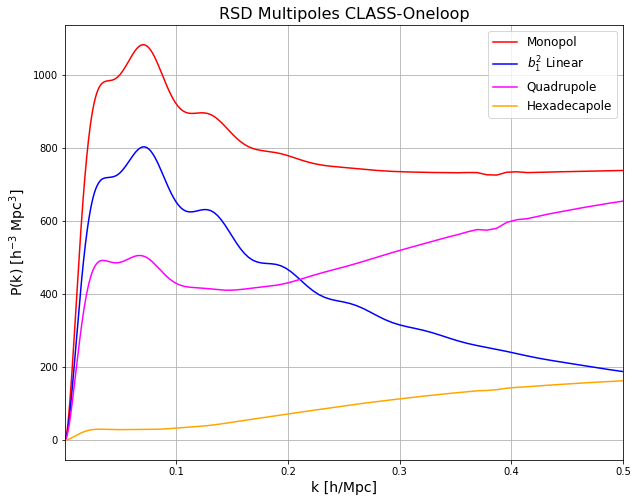

In [6]:
fig = plt.figure(figsize=(10, 8))
sub = fig.add_subplot(1,1,1)
sub.plot(k_arr/h, p_0*h**3*k_arr/h, color = "red", label = "Monopol")
sub.plot(k_arr/h, b1**2 *p_lin*h**3*k_arr/h, color = "blue", label = "$b_1^2$ Linear")
sub.plot(k_arr/h,p_2*h**3*k_arr/h, color = "magenta", label = "Quadrupole")
sub.plot(k_arr/h, p_4*h**3*k_arr/h, color = "orange", label = "Hexadecapole")

sub.set_xlabel(r'k [h/Mpc]', fontsize = 14)
sub.set_ylabel(r'P(k) [h$^{-3}$ Mpc$^3$]', fontsize = 14)
sub.set_xlim(1e-4, 0.5)

plt.title("RSD Multipoles CLASS-Oneloop", fontsize=16)
plt.grid()
plt.legend(fontsize = 12)
# plt.savefig("/home/dennis/Desktop/Plots/CLASS_Multipoles.pdf")
plt.show()

### Importing CLASS-PT Multipoles for the same bias choice

In [8]:
out_pt = "./CLASS_PT_multipoles.txt"
mom_pt = read_bib(out_pt, idx1 = 500)

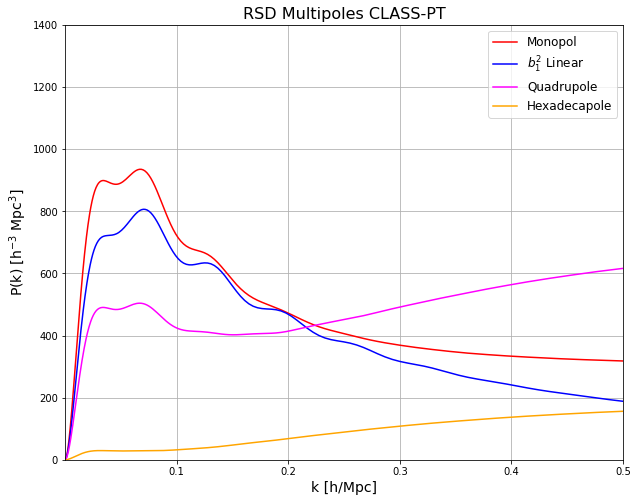

In [8]:
fig = plt.figure(figsize=(10, 8))
sub = fig.add_subplot(1,1,1)
sub.plot(mom_pt["k"]/h, mom_pt["Monopole"]*mom_pt["k"]/h, color = "red", label = "Monopol")
sub.plot(mom_pt["k"]/h, b1**2 *mom_pt["Linear"]*h**3*mom_pt["k"]/h, color = "blue", label = "$b_1^2$ Linear")
sub.plot(mom_pt["k"]/h, mom_pt["Quadrupole"]*mom_pt["k"]/h, color = "magenta", label = "Quadrupole")
sub.plot(mom_pt["k"]/h, mom_pt["Hexadecapole"]*mom_pt["k"]/h, color = "orange", label = "Hexadecapole")

sub.set_xlabel(r'k [h/Mpc]', fontsize = 14)
sub.set_ylabel(r'P(k) [h$^{-3}$ Mpc$^3$]', fontsize = 14)
sub.set_xlim(1e-4, 0.5)
sub.set_ylim(0, 1400)

plt.title("RSD Multipoles CLASS-PT", fontsize=16)
plt.grid()
plt.legend(fontsize = 12)
# plt.savefig("/home/dennis/Desktop/Plots/CLASS_Multipoles.pdf")
plt.show()

## CLASS-PT vs. CLASS-Oneloop

### Linear Power Spectrum

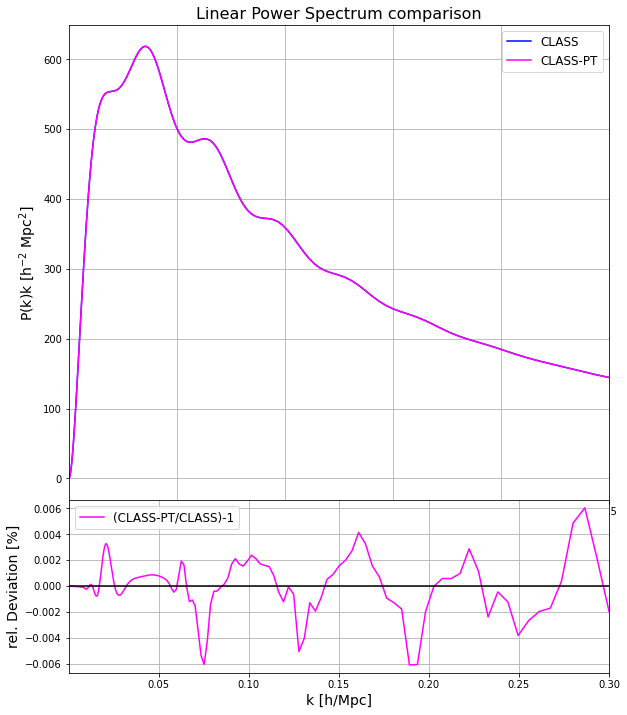

In [14]:
fig = plt.figure(figsize=(10, 12))
sub = fig.add_axes([0.15,0.35,0.75,0.55])
sub.plot(k_arr/h, p_lin*h**3*k_arr/h, color = "blue", label = "CLASS")
sub.plot(mom_pt["k"]/h, mom_pt["Linear"]*h**3*mom_pt["k"]/h, color = "magenta", label = "CLASS-PT")

sub.set_xlabel(r'k [h/Mpc]', fontsize = 14)
sub.set_ylabel(r'P(k)k [h$^{-2}$ Mpc$^2$]', fontsize = 14)
sub.set_xlim(1e-4, 0.5)
# sub.set_ylim(0., 1400)
sub.legend(fontsize = 12)
sub.grid()
sub.set_title("Linear Power Spectrum comparison", fontsize=16)

sub_res= fig.add_axes([0.15,0.15,0.75,0.2])
sub_res.plot(k_arr/h, np.subtract(np.divide(mom_pt["Linear"]*h**3*k_arr/h,p_lin*h**3*k_arr/h)*100., 100.), label = "(CLASS-PT/CLASS)-1", color = "magenta", linestyle = "-")  
sub_res.set_ylabel("rel. Deviation [%]", fontsize = 14)
sub_res.set_xlabel("k [h/Mpc]", fontsize = 14)
sub_res.plot([0.,1.],[0.,0.], color = "k")
sub_res.legend(fontsize = 12)
sub_res.grid()
sub_res.set_xlim(1e-4, 0.3)
# sub_res.set_ylim(-3, 3)

# plt.savefig("/home/dennis/Desktop/Plots/Monopole_comp_v3.pdf")
plt.show()

### Matter Power Spectrum

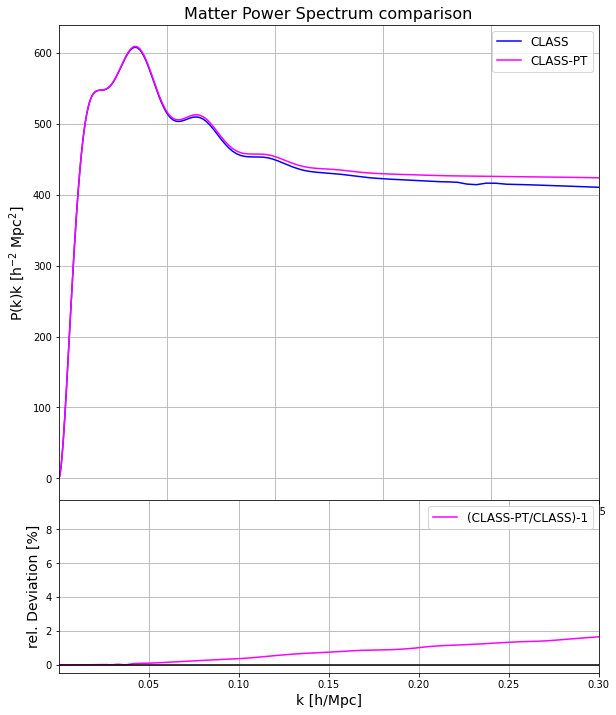

In [15]:
fig = plt.figure(figsize=(10, 12))
sub = fig.add_axes([0.15,0.35,0.75,0.55])
sub.plot(k_arr/h, pk_mm*h**3*k_arr/h, color = "blue", label = "CLASS")
sub.plot(mom_pt["k"]/h, mom_pt["Matter"]*mom_pt["k"]/h, color = "magenta", label = "CLASS-PT")

sub.set_xlabel(r'k [h/Mpc]', fontsize = 14)
sub.set_ylabel(r'P(k)k [h$^{-2}$ Mpc$^2$]', fontsize = 14)
sub.set_xlim(1e-4, 0.5)
# sub.set_ylim(0., 1400)
sub.legend(fontsize = 12)
sub.grid()
sub.set_title("Matter Power Spectrum comparison", fontsize=16)

sub_res= fig.add_axes([0.15,0.15,0.75,0.2])
sub_res.plot(k_arr/h, np.subtract(np.divide(mom_pt["Matter"]*k_arr/h,pk_mm*h**3*k_arr/h)*100., 100.), label = "(CLASS-PT/CLASS)-1", color = "magenta", linestyle = "-")  
sub_res.set_ylabel("rel. Deviation [%]", fontsize = 14)
sub_res.set_xlabel("k [h/Mpc]", fontsize = 14)
sub_res.plot([0.,1.],[0.,0.], color = "k")
sub_res.legend(fontsize = 12)
sub_res.grid()
sub_res.set_xlim(1e-4, 0.3)
# sub_res.set_ylim(-3, 3)

# plt.savefig("/home/dennis/Desktop/Plots/Monopole_comp_v3.pdf")
plt.show()

### Galaxy Power Spectrum

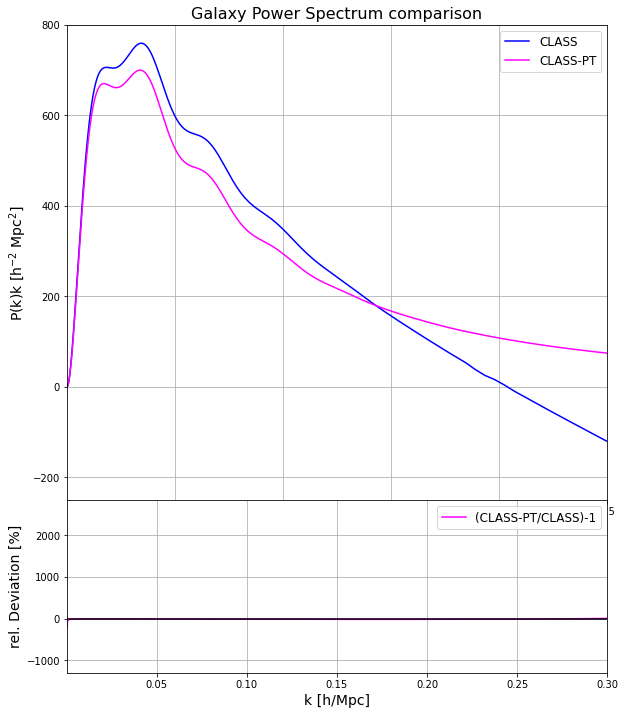

In [17]:
fig = plt.figure(figsize=(10, 12))
sub = fig.add_axes([0.15,0.35,0.75,0.55])
sub.plot(k_arr/h, pk_gg*h**3*k_arr/h, color = "blue", label = "CLASS")
sub.plot(mom_pt["k"]/h, mom_pt["Galaxy"]*mom_pt["k"]/h, color = "magenta", label = "CLASS-PT")

sub.set_xlabel(r'k [h/Mpc]', fontsize = 14)
sub.set_ylabel(r'P(k)k [h$^{-2}$ Mpc$^2$]', fontsize = 14)
sub.set_xlim(1e-4, 0.5)
sub.set_ylim(-250, 800)
sub.legend(fontsize = 12)
sub.grid()
sub.set_title("Galaxy Power Spectrum comparison", fontsize=16)

sub_res= fig.add_axes([0.15,0.15,0.75,0.2])
sub_res.plot(k_arr/h, np.subtract(np.divide(mom_pt["Galaxy"]*k_arr/h,pk_gg*h**3*k_arr/h)*100., 100.), label = "(CLASS-PT/CLASS)-1", color = "magenta", linestyle = "-")  
sub_res.set_ylabel("rel. Deviation [%]", fontsize = 14)
sub_res.set_xlabel("k [h/Mpc]", fontsize = 14)
sub_res.plot([0.,1.],[0.,0.], color = "k")
sub_res.legend(fontsize = 12)
sub_res.grid()
sub_res.set_xlim(1e-4, 0.3)
# sub_res.set_ylim(-3, 3)

# plt.savefig("/home/dennis/Desktop/Plots/Monopole_comp_v3.pdf")
plt.show()

### RSD Monopole

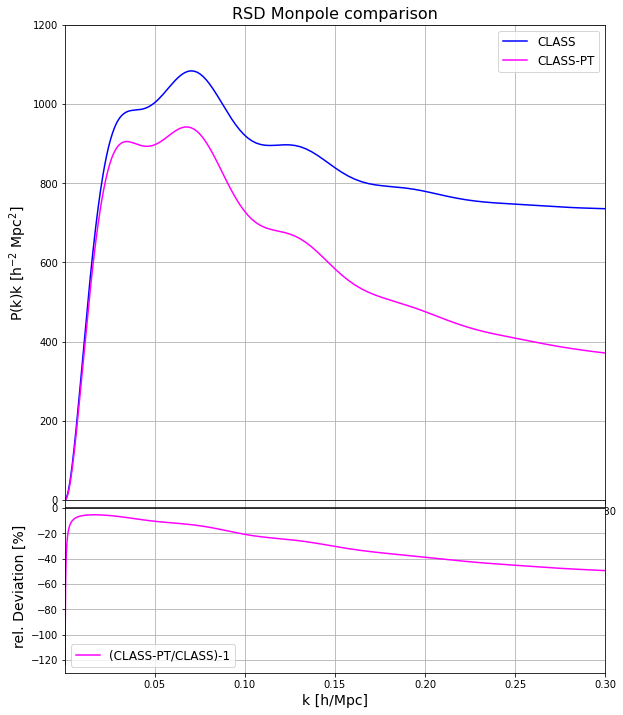

In [19]:
fig = plt.figure(figsize=(10, 12))
sub = fig.add_axes([0.15,0.35,0.75,0.55])
sub.plot(k_arr/h, p_0*h**3*k_arr/h, color = "blue", label = "CLASS")
sub.plot(mom_pt["k"]/h, mom_pt["Monopole"]*mom_pt["k"]/h, color = "magenta", label = "CLASS-PT")

sub.set_xlabel(r'k [h/Mpc]', fontsize = 14)
sub.set_ylabel(r'P(k)k [h$^{-2}$ Mpc$^2$]', fontsize = 14)
sub.set_xlim(1e-4, 0.3)
sub.set_ylim(0., 1200)
sub.legend(fontsize = 12)
sub.grid()
sub.set_title("RSD Monpole comparison", fontsize=16)

sub_res= fig.add_axes([0.15,0.15,0.75,0.2])
sub_res.plot(k_arr/h, np.subtract(np.divide(mom_pt["Monopole"]*k_arr/h,p_0*h**3*k_arr/h)*100., 100.), label = "(CLASS-PT/CLASS)-1", color = "magenta", linestyle = "-")  
sub_res.set_ylabel("rel. Deviation [%]", fontsize = 14)
sub_res.set_xlabel("k [h/Mpc]", fontsize = 14)
sub_res.plot([0.,1.],[0.,0.], color = "k")
sub_res.legend(fontsize = 12)
sub_res.grid()
sub_res.set_xlim(1e-4, 0.3)
# sub_res.set_ylim(-3, 3)

# plt.savefig("/home/dennis/Desktop/Plots/Monopole_comp_v3.pdf")
plt.show()

### Quadrupole

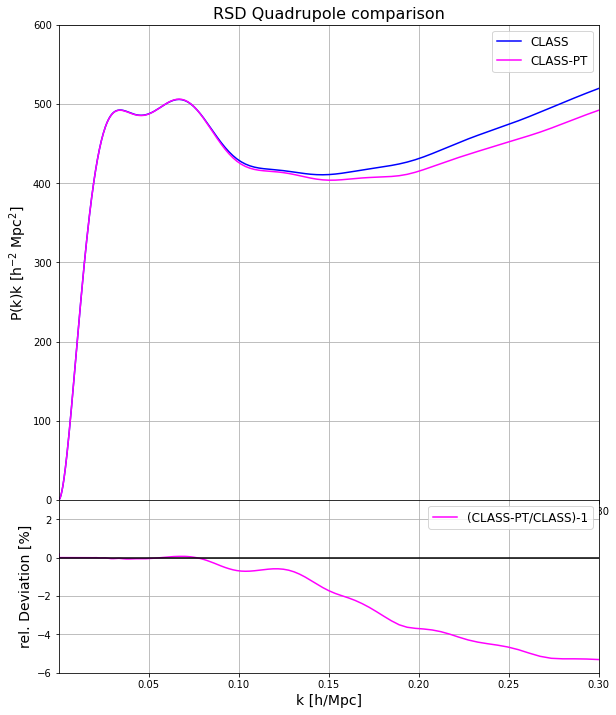

In [20]:
fig = plt.figure(figsize=(10, 12))
sub = fig.add_axes([0.15,0.35,0.75,0.55])
sub.plot(k_arr/h, p_2*h**3*k_arr/h, color = "blue", label = "CLASS")
sub.plot(mom_pt["k"]/h, mom_pt["Quadrupole"]*mom_pt["k"]/h, color = "magenta", label = "CLASS-PT")

sub.set_xlabel(r'k [h/Mpc]', fontsize = 14)
sub.set_ylabel(r'P(k)k [h$^{-2}$ Mpc$^2$]', fontsize = 14)
sub.set_xlim(1e-4, 0.3)
sub.set_ylim(0., 600)
sub.legend(fontsize = 12)
sub.grid()
sub.set_title("RSD Quadrupole comparison", fontsize=16)

sub_res= fig.add_axes([0.15,0.15,0.75,0.2])
sub_res.plot(k_arr/h, np.subtract(np.divide(mom_pt["Quadrupole"]*k_arr/h,p_2*h**3*k_arr/h)*100., 100.), label = "(CLASS-PT/CLASS)-1", color = "magenta", linestyle = "-")  
sub_res.set_ylabel("rel. Deviation [%]", fontsize = 14)
sub_res.set_xlabel("k [h/Mpc]", fontsize = 14)
sub_res.plot([0.,1.],[0.,0.], color = "k")
sub_res.legend(fontsize = 12)
sub_res.grid()
sub_res.set_xlim(1e-4, 0.3)
sub_res.set_ylim(-6, 3)

# plt.savefig("/home/dennis/Desktop/Plots/Quadrupole_comp_v3.pdf")
plt.show()

### Hexadecapole

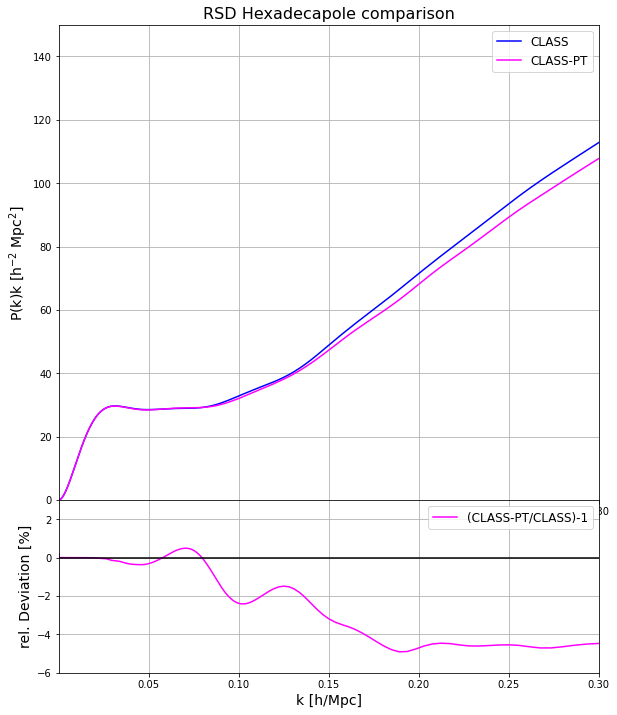

In [21]:
fig = plt.figure(figsize=(10, 12))
sub = fig.add_axes([0.15,0.35,0.75,0.55])
sub.plot(k_arr/h, p_4*h**3*k_arr/h, color = "blue", label = "CLASS")
sub.plot(mom_pt["k"]/h, mom_pt["Hexadecapole"]*mom_pt["k"]/h, color = "magenta", label = "CLASS-PT")

sub.set_xlabel(r'k [h/Mpc]', fontsize = 14)
sub.set_ylabel(r'P(k)k [h$^{-2}$ Mpc$^2$]', fontsize = 14)
sub.set_xlim(1e-4, 0.3)
sub.set_ylim(0., 150)
sub.legend(fontsize = 12)
sub.grid()
sub.set_title("RSD Hexadecapole comparison", fontsize=16)

sub_res= fig.add_axes([0.15,0.15,0.75,0.2])
sub_res.plot(k_arr/h, np.subtract(np.divide(mom_pt["Hexadecapole"]*k_arr/h,p_4*h**3*k_arr/h)*100., 100.), label = "(CLASS-PT/CLASS)-1", color = "magenta", linestyle = "-")  
sub_res.set_ylabel("rel. Deviation [%]", fontsize = 14)
sub_res.set_xlabel("k [h/Mpc]", fontsize = 14)
sub_res.plot([0.,1.],[0.,0.], color = "k")
sub_res.legend(fontsize = 12)
sub_res.grid()
sub_res.set_xlim(1e-4, 0.3)
sub_res.set_ylim(-6, 3)

# plt.savefig("/home/dennis/Desktop/Plots/Hexadecapole_comp_v3.pdf")
plt.show()